## Homework 2: Stochastic Gradient Descent

### Exercise 3: SGD in 2D

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def L(theta):
    theta = np.asarray(theta, dtype=float)
    t1, t2 = theta[0], theta[1]
    return (t1**2 - 1.0)**2 + 10.0 * (t2 - t1**2)**2

def grad_L(theta):
    theta = np.asarray(theta, dtype=float)
    t1, t2 = theta[0], theta[1]
    g1 = 4.0 * t1 * (t1**2 - 1.0) - 40.0 * t1 * (t2 - t1**2)
    g2 = 20.0 * (t2 - t1**2)

    return np.array([g1, g2], dtype=float)

In [21]:
def sgd_noisy(theta0, eta, sigma2, maxit=2000, tolL=1e-6, toltheta=1e-8, seed=0):
    rng = np.random.default_rng(seed)

    theta = np.asarray(theta0, dtype=float).copy()
    thetas = [theta.copy()]
    losses = [L(theta)]

    for it in range(maxit):
        g = grad_L(theta)

        # stopping: small true gradient
        if np.linalg.norm(g) < tolL:
            break

        # noise ~ N(0, sigma^2 I)  => std = sqrt(sigma^2)
        noise = rng.normal(0.0, np.sqrt(sigma2), size=2)
        gk = g + noise

        theta_next = theta - eta * gk

        # stopping: small parameter change
        if np.linalg.norm(theta_next - theta) < toltheta:
            theta = theta_next
            thetas.append(theta.copy())
            losses.append(L(theta))
            break

        theta = theta_next
        thetas.append(theta.copy())
        losses.append(L(theta))

    return theta, it, np.array(thetas), np.array(losses)

In [22]:
def levelsets(axis, xlim=(-2, 2), ylim=(-1, 3), ngrid=400, ncontours=20, use_log_levels=True):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)

    Z = (X**2 - 1.0)**2 + 10.0 * (Y - X**2)**2

    if use_log_levels:
        levels = np.logspace(-2, 3, ncontours)
        cs = axis.contour(X, Y, Z, levels=levels)
    else:
        cs = axis.contour(X, Y, Z, levels=ncontours)

    axis.clabel(cs, inline=True, fontsize=7)
    axis.axhline(0, lw=0.5, color="k")
    axis.axvline(0, lw=0.5, color="k")
    axis.set_aspect("equal", "box")
    axis.set_xlabel(r"$\theta_1$")
    axis.set_ylabel(r"$\theta_2$")
    axis.grid(alpha=0.2)
    axis.set_xlim(xlim)
    axis.set_ylim(ylim)
    
def plot_trajectory(ax, thetas, title="", xlim=(-2,2), ylim=(-1,3), ncontours=20):
    levelsets(ax, xlim=xlim, ylim=ylim, ncontours=ncontours, use_log_levels=False)

    c1 = np.array([0.7, 0.7, 1.0])
    c2 = np.array([0.0, 0.0, 0.8])
    colors = [c1 + (c2 - c1) * t for t in np.linspace(0, 1, len(thetas))]

    ax.plot(thetas[:, 0], thetas[:, 1], linewidth=0.9, zorder=2)
    ax.scatter(thetas[:, 0], thetas[:, 1], c=colors, s=10, zorder=3, label="successive thetas")
    ax.set_title(title, fontsize=12)
    ax.legend(loc="lower center", fontsize=7)
    
def plot_all_runs(theta0_list, eta_list, sigma2_list, maxit=2000, xlim=(-2,2), ylim=(-1,3), ncontours=20):
    for theta0 in theta0_list:
        # format title like: theta_0 = (-1.5, 2)
        t0 = (float(theta0[0]), float(theta0[1]))
        fig, axs = plt.subplots(len(sigma2_list), len(eta_list), figsize=(4*len(eta_list), 3.6*len(sigma2_list)))
        fig.suptitle(f"theta_0 = ({t0[0]:.2f}, {t0[1]:.2f})", fontsize=18)

        # if only one row/col, axs may not be 2D
        axs = np.atleast_2d(axs)

        for r, sigma2 in enumerate(sigma2_list):
            for c, eta in enumerate(eta_list):
                _, _, thetas, _ = sgd_noisy(
                    theta0=theta0,
                    eta=eta,
                    sigma2=sigma2,
                    maxit=maxit,
                    tolL=1e-6,
                    toltheta=1e-10,
                    seed=123
                )

                title = fr"$\eta={eta}$, $\sigma^2={sigma2}$"
                plot_trajectory(axs[r, c], thetas, title=title, xlim=xlim, ylim=ylim, ncontours=ncontours)

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()

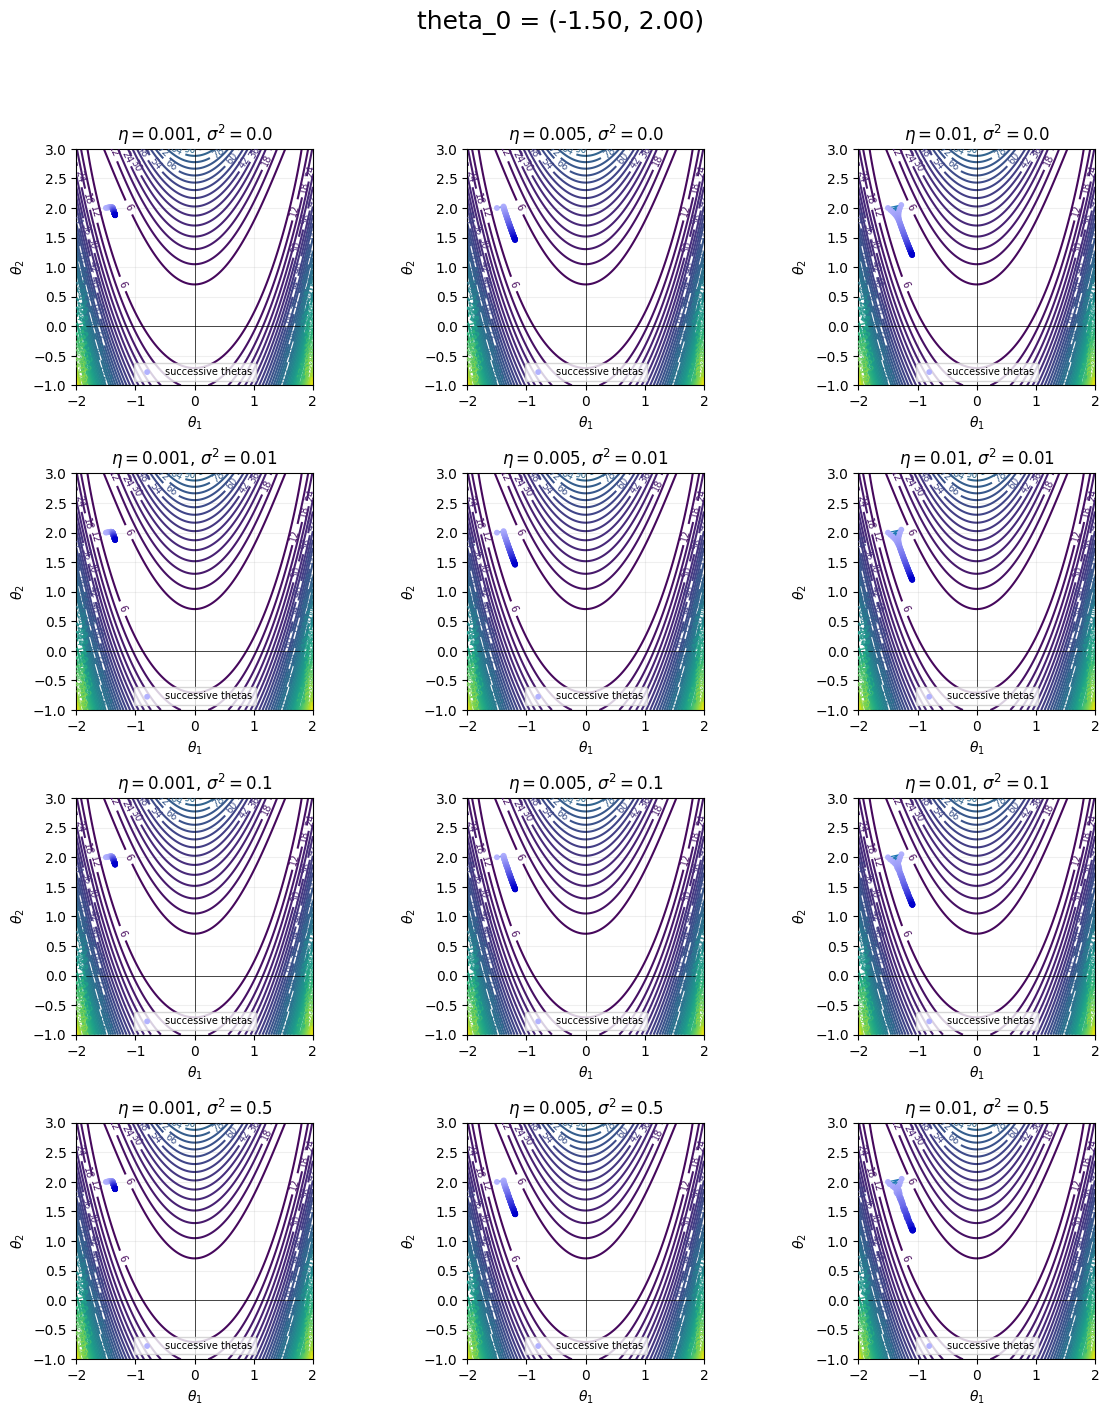

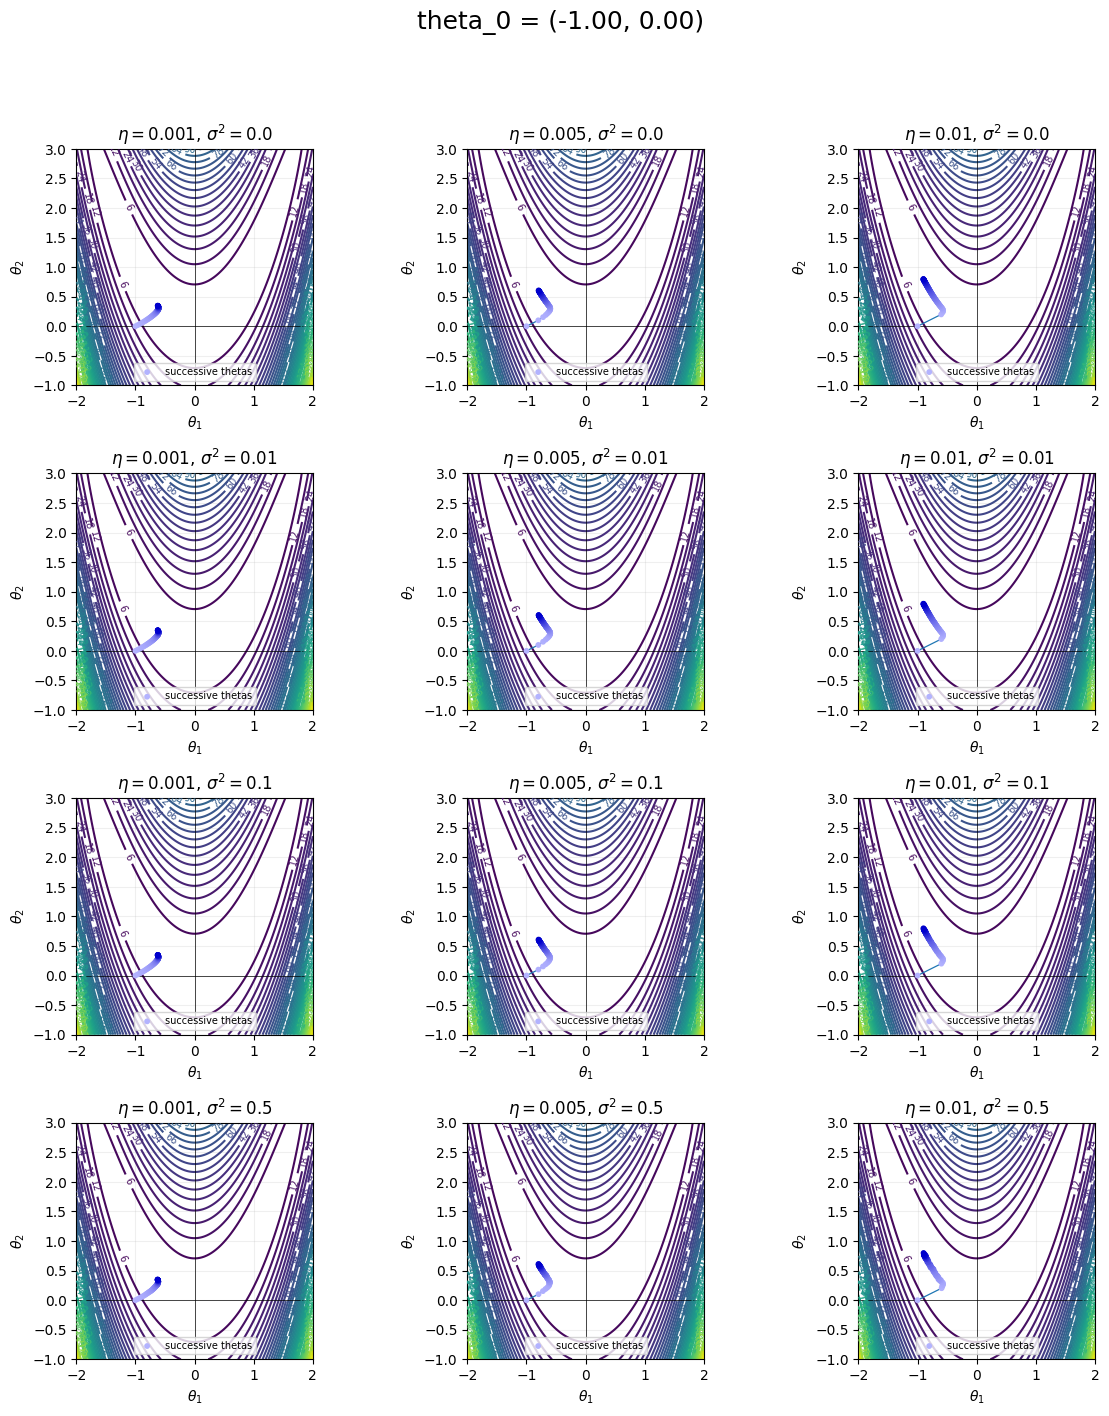

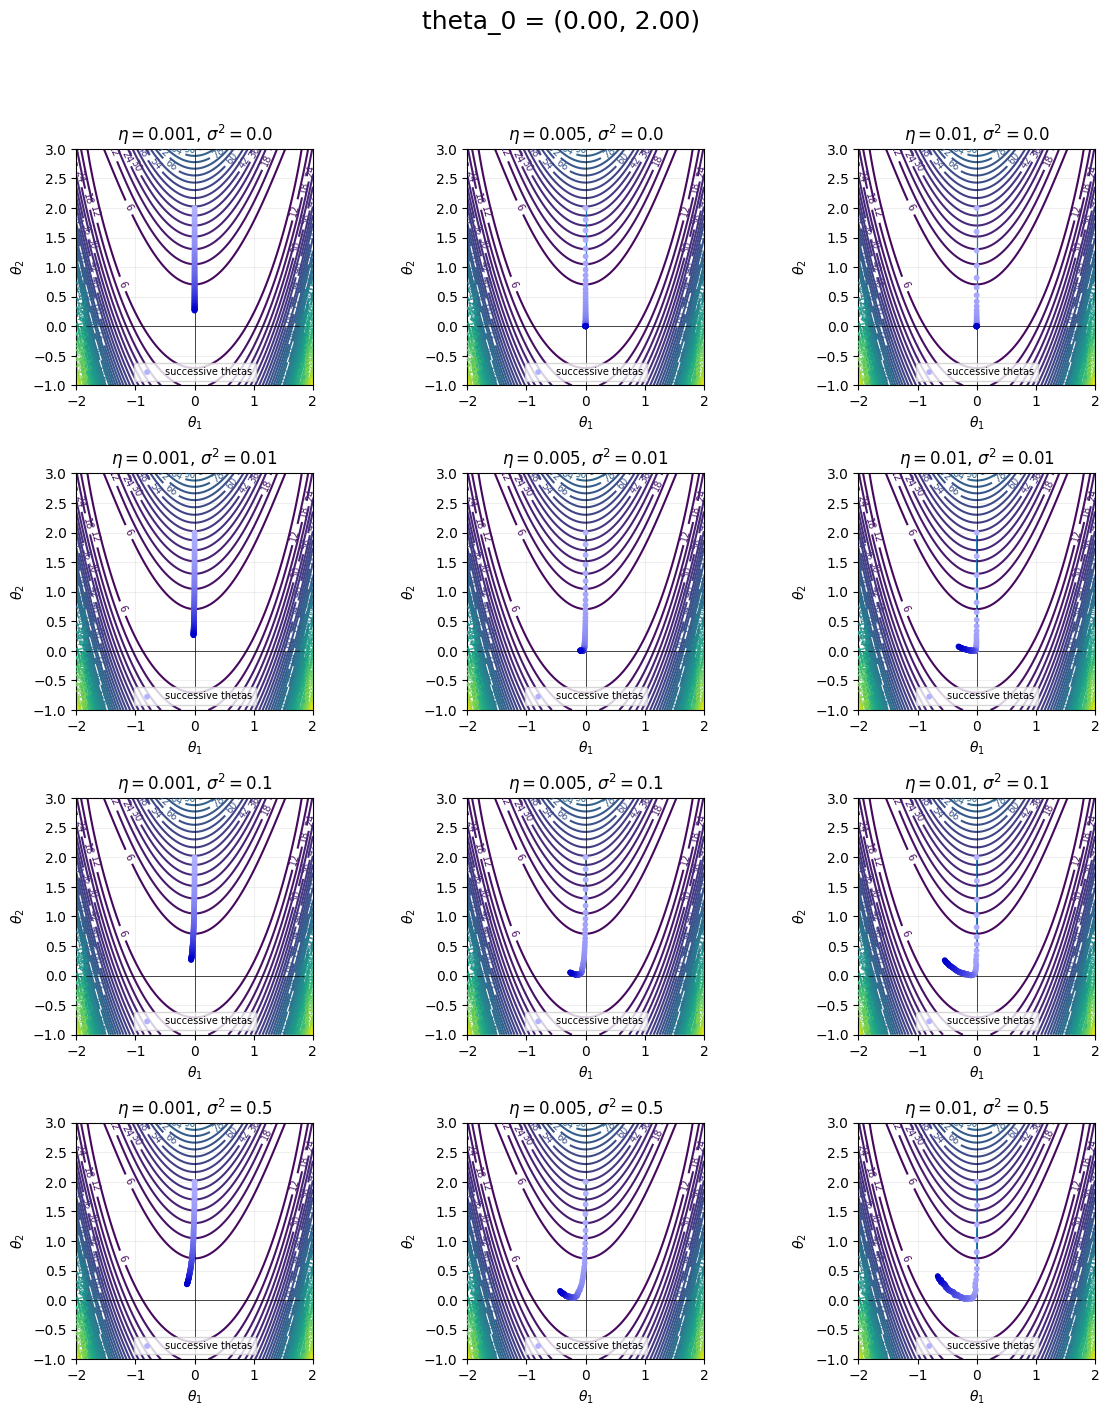

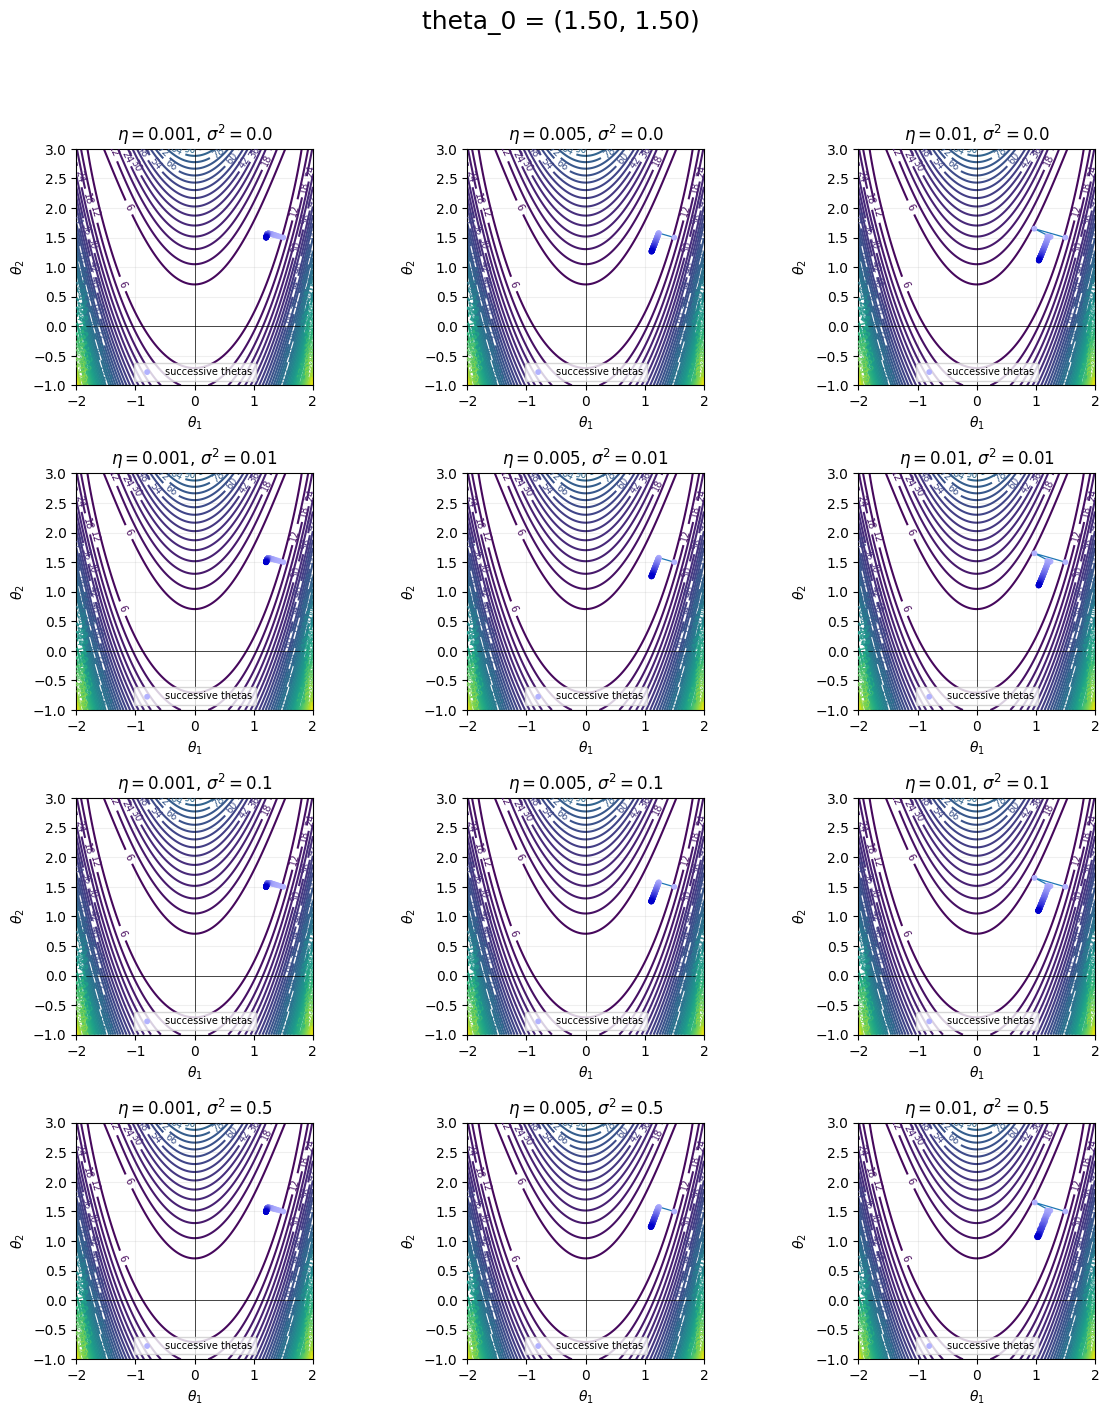

In [23]:
theta0_list = [
    (-1.5, 2.0),
    (-1.0, 0.0),
    (0.0, 2.0),
    (1.5, 1.5),
]

eta_list = [1e-3, 5e-3, 1e-2]
sigma2_list = [0.0, 0.01, 0.1, 0.5]

plot_all_runs(
    theta0_list=theta0_list,
    eta_list=eta_list,
    sigma2_list=sigma2_list,
    maxit=100,
    xlim=(-2, 2),
    ylim=(-1, 3),
    ncontours=50
)